In [9]:
## 1️⃣ Section: Imports + Load Data

In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [8]:
df = pd.read_csv("../data/raw/spam.tsv", sep="\t", header=None)
df.columns = ["label", "text"]
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [11]:
## 3️⃣ Section: Basic Stats & EDA
df['length'] = df['clean_text'].apply(len)

# Stats
length_stats = df.groupby('label')['length'].describe()
print(length_stats)

        count        mean        std   min    25%    50%    75%    max
label                                                                 
0      4825.0   68.530155  55.648830   1.0   32.0   50.0   89.0  908.0
1       747.0  134.373494  27.883153  13.0  129.0  145.0  152.0  212.0


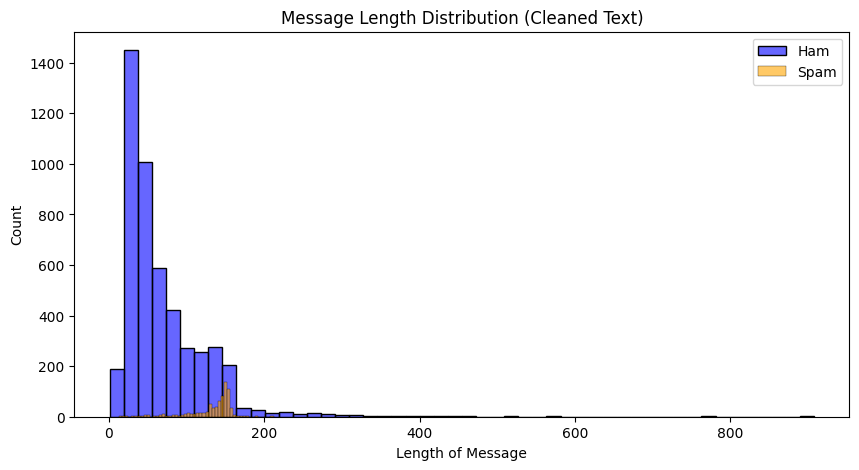

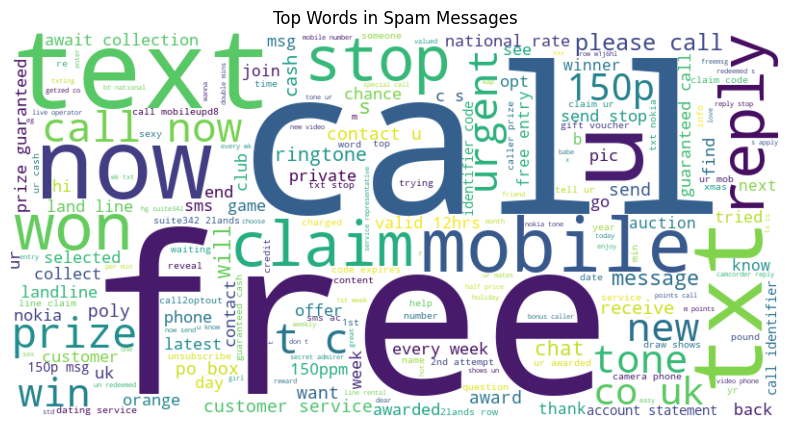

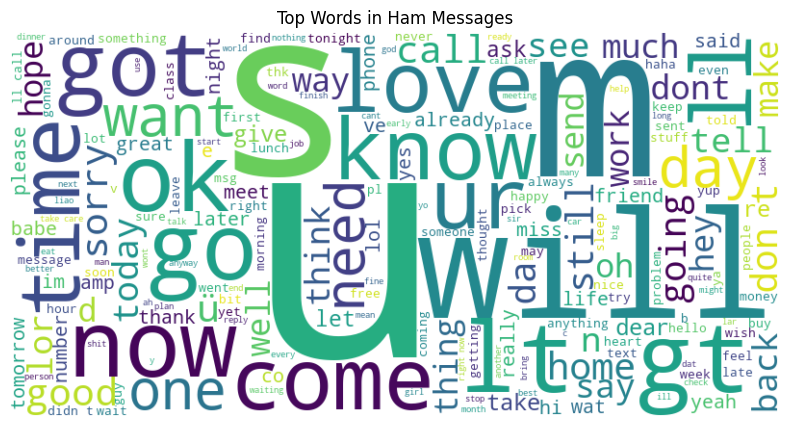

In [12]:
## plots
# Length histogram
plt.figure(figsize=(10,5))
sns.histplot(df[df['label']==0]['length'], color='blue', label='Ham', bins=50, alpha=0.6)
sns.histplot(df[df['label']==1]['length'], color='orange', label='Spam', bins=50, alpha=0.6)
plt.title("Message Length Distribution (Cleaned Text)")
plt.xlabel("Length of Message")
plt.ylabel("Count")
plt.legend()
plt.show()

# Word Clouds
spam_text = " ".join(df[df['label']==1]['clean_text'])
ham_text = " ".join(df[df['label']==0]['clean_text'])

# Spam
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text)
plt.figure(figsize=(10,5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in Spam Messages")
plt.show()

# Ham
ham_wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text)
plt.figure(figsize=(10,5))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in Ham Messages")
plt.show()

In [13]:
## 5️⃣ Section: Save Cleaned Data
df.to_csv("../data/processed/spam_cleaned.csv", index=False)